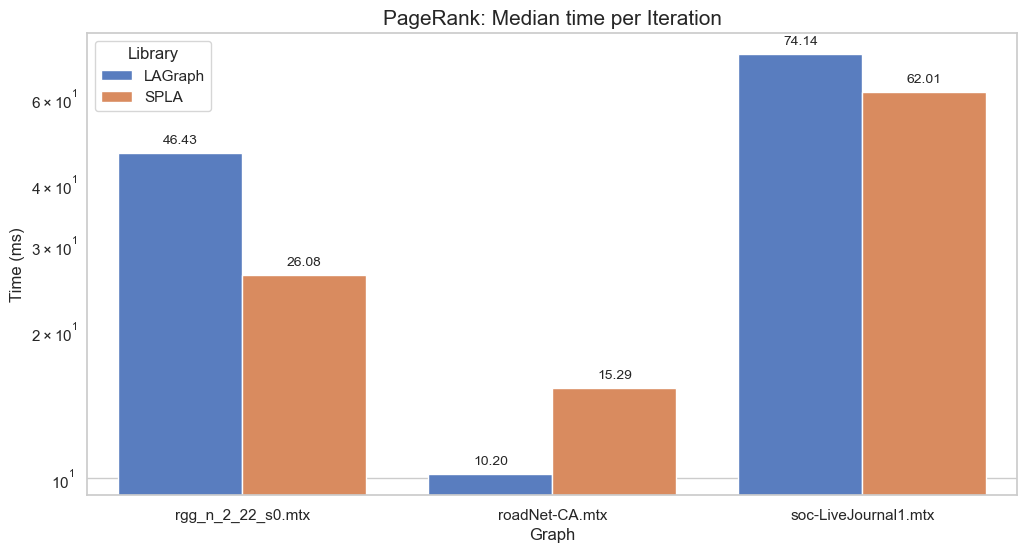

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Функция статистики
def get_stats(group):
    data = group['MS_per_Iter']
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data) if n > 1 else 0
    
    p_val = stats.shapiro(data)[1] if n >= 3 else np.nan
    
    if n > 1:
        ci = stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    else:
        ci = (mean, mean)
        
    return pd.Series({
        'Mean_ms': mean,
        'Median_ms': np.median(data),
        'CI_lower': ci[0],
        'CI_upper': ci[1],
        'Std_Err': std_err,
        'P_Normal': p_val,
        'Sample_Size': n
    })

# Загрузка
try:
    df_pr = pd.read_csv('pr/pr_results.csv')
except FileNotFoundError:
    print("Ошибка: Файл pr/pr_results.csv не найден!")
    # Создадим пустой DF для примера, чтобы код не падал, если файла нет
    df_pr = pd.DataFrame(columns=['Graph', 'Library', 'Device', 'MS_per_Iter', 'Iters'])

graph_info = {
    'soc-LiveJournal1.mtx': {'edges': 68993773, 'desc': 'Social (Power-law)'},
    'roadNet-CA.mtx': {'edges': 5533214, 'desc': 'Road (Low-degree)'},
    'rgg_n_2_22_s0.mtx': {'edges': 33554432, 'desc': 'Random (Regular)'}
}

# Очистка и расчет статистики
df_clean = df_pr[~((df_pr['Library'] == 'SPLA') & (df_pr['Iters'] == 1))].copy()
df_stats = df_clean.groupby(['Graph', 'Library', 'Device']).apply(get_stats).reset_index()

# Отрисовка (Теперь plt точно будет определен, так как импорт в этом же блоке)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Используем Median_ms для графиков
ax = sns.barplot(data=df_stats, x='Graph', y='Median_ms', hue='Library', palette='muted')

# Добавляем подписи над столбцами
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(format(h, '.2f'), 
                    (p.get_x() + p.get_width() / 2., h), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points', fontsize=10)

plt.title('PageRank: Median time per Iteration', fontsize=15)
plt.ylabel('Time (ms)')
plt.yscale('log')

import os
if not os.path.exists('pr'):
    os.makedirs('pr')

plt.savefig("pr/median_time.png")
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_25472/1750167759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pivot_df, x='Graph', y='Speedup', palette='magma')


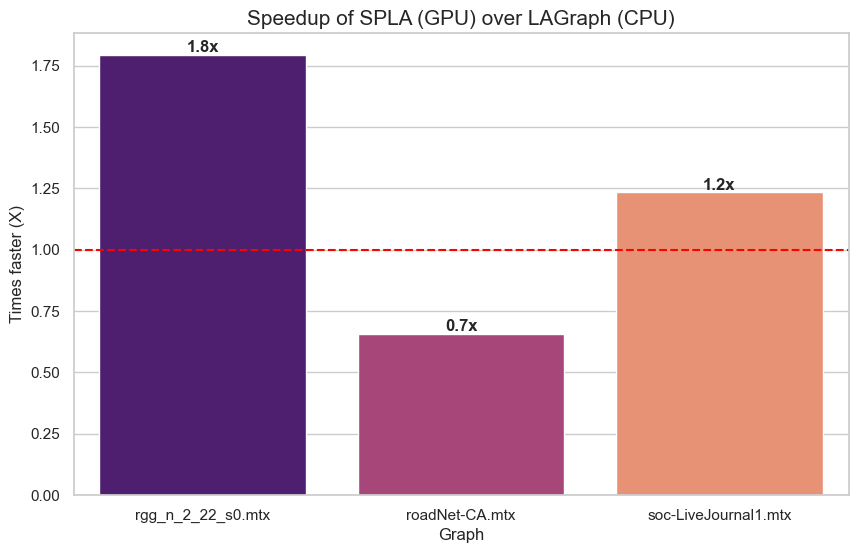

<Figure size 640x480 with 0 Axes>

In [7]:
# Рассчитываем Speedup
pivot_df = df_stats.pivot(index='Graph', columns='Library', values='Mean_ms')
pivot_df['Speedup'] = pivot_df['LAGraph'] / pivot_df['SPLA']
pivot_df = pivot_df.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=pivot_df, x='Graph', y='Speedup', palette='magma')

plt.axhline(1.0, color='red', linestyle='--', label='Baseline (CPU)')
plt.title('Speedup of SPLA (GPU) over LAGraph (CPU)', fontsize=15)
plt.ylabel('Times faster (X)')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + 'x', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', fontsize=12, fontweight='bold')
plt.show()
plt.savefig("pr/speedup.png")


Колонки в df_stats: Index(['Graph', 'Library', 'Device', 'Mean_ms', 'Median_ms', 'CI_lower',
       'CI_upper', 'Std_Err', 'P_Normal', 'Sample_Size', 'GTEPS'],
      dtype='str')


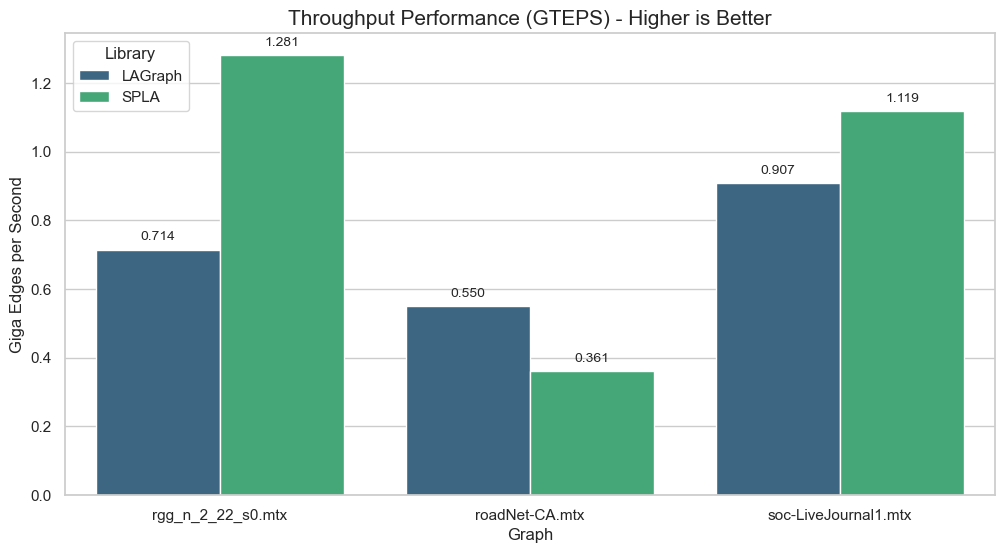

In [8]:
# 1. Сначала рассчитываем GTEPS (если вы этого еще не сделали в этой сессии)
def calc_gteps(row):
    # Берем данные из вашего словаря graph_info
    if row['Graph'] in graph_info:
        edges = graph_info[row['Graph']]['edges']
        # Формула: Ребра / (Время в мс * 10^6) 
        # (ms * 10^6 превращает миллисекунды в наносекунды для получения Гига-коэффициента)
        if row['Mean_ms'] > 0:
            return edges / (row['Mean_ms'] * 1e6)
    return 0

# ПРИМЕНЯЕМ расчет к df_stats
df_stats['GTEPS'] = df_stats.apply(calc_gteps, axis=1)

# Проверка: напечатайте колонки, чтобы убедиться, что GTEPS появился
print("Колонки в df_stats:", df_stats.columns)

# 2. Теперь строим график
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Теперь 'GTEPS' точно есть в данных
ax = sns.barplot(data=df_stats, x='Graph', y='GTEPS', hue='Library', palette='viridis')

# Добавляем подписи значений над столбцами
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(format(h, '.3f'), 
                    (p.get_x() + p.get_width() / 2., h), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points', fontsize=10)

plt.title('Throughput Performance (GTEPS) - Higher is Better', fontsize=15)
plt.ylabel('Giga Edges per Second')
plt.savefig("pr/throughput.png")

plt.show()